# METRICAS #

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast # Para convertir strings de listas en listas reales de Python al leer CSVs

# Configuración visual para gráficos (Estilo profesional para Urban Soul)
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 7)

# Celda 2: Definición de las Funciones de Métricas #

In [2]:
def calcular_accuracy(tp, tn, fp, fn):
    return (tp + tn) / (tp + tn + fp + fn)

def calcular_precision(tp, fp):
    if (tp + fp) == 0: return 0.0
    return tp / (tp + fp)

def calcular_recall(tp, fn):
    if (tp + fn) == 0: return 0.0
    return tp / (tp + fn)

def calcular_f1_score(precision, recall):
    if (precision + recall) == 0: return 0.0
    return 2 * (precision * recall) / (precision + recall)

# --- MÉTRICAS TOP-K PARA RECOMENDADORES ---
def hit_rate_at_k(recomendaciones, items_relevantes, k):
    """Calcula la proporción de veces que al menos un item relevante aparece en el Top-K."""
    aciertos = 0
    total_consultas = len(recomendaciones)
    for i in range(total_consultas):
        rec_k = recomendaciones[i][:k]
        if any(item in rec_k for item in items_relevantes[i]):
            aciertos += 1
    return aciertos / total_consultas if total_consultas > 0 else 0.0

def precision_at_k(recomendaciones, items_relevantes, k):
    """Calcula cuántas de las recomendaciones en el Top-K fueron relevantes."""
    precisiones = []
    for recs, rels in zip(recomendaciones, items_relevantes):
        recs_k = recs[:k]
        relevantes_en_k = len(set(recs_k).intersection(set(rels)))
        precisiones.append(relevantes_en_k / k)
    return np.mean(precisiones)

def recall_at_k(recomendaciones, items_relevantes, k):
    """Calcula cuántos de los items relevantes totales fueron encontrados en el Top-K."""
    recalls = []
    for recs, rels in zip(recomendaciones, items_relevantes):
        recs_k = recs[:k]
        relevantes_en_k = len(set(recs_k).intersection(set(rels)))
        total_relevantes = len(rels)
        if total_relevantes > 0:
            recalls.append(relevantes_en_k / total_relevantes)
        else:
            recalls.append(0.0)
    return np.mean(recalls)

def calcular_dcg_at_k(recs_k, dict_relevancia):
    """Calcula el Discounted Cumulative Gain."""
    dcg = 0.0
    for i, item in enumerate(recs_k):
        rel_i = dict_relevancia.get(item, 0)
        dcg += rel_i / np.log2(i + 2) # i+2 equivale a posicion+1 porque el índice inicia en 0
    return dcg

def ndcg_at_k(recomendaciones, diccionarios_relevancia, k):
    """Calcula el Normalized Discounted Cumulative Gain penalizando posiciones inferiores."""
    ndcgs = []
    for recs, dict_rel in zip(recomendaciones, diccionarios_relevancia):
        recs_k = recs[:k]
        dcg = calcular_dcg_at_k(recs_k, dict_rel)
        
        # IDCG: El mejor escenario posible ordenando por relevancia real
        items_ideales = sorted(dict_rel.keys(), key=lambda x: dict_rel[x], reverse=True)[:k]
        idcg = calcular_dcg_at_k(items_ideales, dict_rel)
        
        if idcg > 0:
            ndcgs.append(dcg / idcg)
        else:
            ndcgs.append(0.0)
    return np.mean(ndcgs)

# CELDA 3: Carga de Datos y Preparación #

In [3]:
# PARÁMETRO GLOBAL DE EVALUACIÓN
K = 5

# ------------------------------------------------------------------------------
# MODO SIMULACIÓN (Activo por defecto para que pruebes el notebook)
# ------------------------------------------------------------------------------
# Simulamos 3 usuarios de prueba y los items con los que realmente interactuaron
items_relevantes = [
    [1001, 1005],              # Usuario 1 interactuó con P1001 y P1005
    [1008, 1001, 1002],        # Usuario 2
    [1010]                     # Usuario 3
]

# Diccionarios de relevancia para NDCG (3: compró, 2: carrito, 1: vista)
relevancia_usuarios = [
    {1001: 3, 1005: 2, 1003: 0},
    {1008: 3, 1001: 3, 1002: 2, 1009: 1},
    {1010: 3}
]

# Predicciones simuladas de cada modelo
preds_base = [[1099, 1098, 1097, 1096, 1095], [1099, 1098, 1097, 1096, 1095], [1099, 1098, 1097, 1096, 1095]]
preds_ml   = [[1001, 1099, 1004, 1096, 1005], [1008, 1002, 1011, 1099, 1007], [1011, 1012, 1013, 1014, 1015]]
preds_dl   = [[1003, 1005, 1001, 1096, 1099], [1008, 1001, 1011, 1002, 1007], [1010, 1012, 1013, 1014, 1015]]
preds_hib  = [[1001, 1005, 1003, 1004, 1099], [1008, 1001, 1002, 1011, 1007], [1010, 1011, 1012, 1013, 1014]]


# ------------------------------------------------------------------------------
# MODO PRODUCCIÓN (Descomentar cuando tengas los CSV exportados de ml.ipynb y dl.ipynb)
# ------------------------------------------------------------------------------

# 1. Cargar el Ground Truth (Set de Testing extraído de 2020-Apr-L.csv)
# df_testing = pd.read_csv('../../data/processed/testing_set.csv')
# items_relevantes = df_testing['items_interactuados'].apply(ast.literal_eval).tolist()
# relevancia_usuarios = df_testing['diccionario_relevancia'].apply(ast.literal_eval).tolist()

# 2. Cargar las predicciones de los modelos
# df_preds_base = pd.read_csv('../../data/processed/predicciones_baseline.csv')
# df_preds_ml = pd.read_csv('../data/predicciones_ml.csv')
# df_preds_dl = pd.read_csv('../data/predicciones_dl.csv')
# df_preds_hib = pd.read_csv('../data/predicciones_hibrido.csv')

# 3. Convertir strings a listas reales
# preds_base = df_preds_base['recomendaciones'].apply(ast.literal_eval).tolist()
# preds_ml = df_preds_ml['recomendaciones'].apply(ast.literal_eval).tolist()
# preds_dl = df_preds_dl['recomendaciones'].apply(ast.literal_eval).tolist()
# preds_hib = df_preds_hib['recomendaciones'].apply(ast.literal_eval).tolist()
print("Datos cargados exitosamente.")

Datos cargados exitosamente.


# CELDA 4: Ejecución y Almacenamiento de Resultados #

In [4]:
modelos = ['Baseline\n(Más Vendidos)', 'Torre A\n(Solo ML)', 'Torre B\n(Solo DL)', 'Torre C\n(Híbrido)']
resultados_precision = []
resultados_recall = []
resultados_ndcg = []
resultados_hr = []

listas_predicciones = [preds_base, preds_ml, preds_dl, preds_hib]

for preds in listas_predicciones:
    resultados_precision.append(precision_at_k(preds, items_relevantes, K))
    resultados_recall.append(recall_at_k(preds, items_relevantes, K))
    resultados_ndcg.append(ndcg_at_k(preds, relevancia_usuarios, K))
    resultados_hr.append(hit_rate_at_k(preds, items_relevantes, K))

# Mostrar resultados tabulares
df_resultados = pd.DataFrame({
    'Modelo': ['Baseline', 'Torre A (ML)', 'Torre B (DL)', 'Torre C (Híbrido)'],
    f'Precision@{K}': resultados_precision,
    f'Recall@{K}': resultados_recall,
    f'NDCG@{K}': resultados_ndcg,
    f'HR@{K}': resultados_hr
})

print("=== RESUMEN DE EVALUACIÓN TOP-{} ===".format(K))
display(df_resultados)

=== RESUMEN DE EVALUACIÓN TOP-5 ===


,Modelo,Precision@5,Recall@5,NDCG@5,HR@5
0,Baseline,0.000000,0.000000,0.000000,0.000000
1,Torre A (ML),0.266667,0.555556,0.519812,0.666667
2,Torre B (DL),0.400000,1.000000,0.852669,1.000000
3,Torre C (Híbrido),0.400000,1.000000,0.977297,1.000000


# CELDA 5: Proyección de Resultados: Precision@K y Recall@K por Modelo #

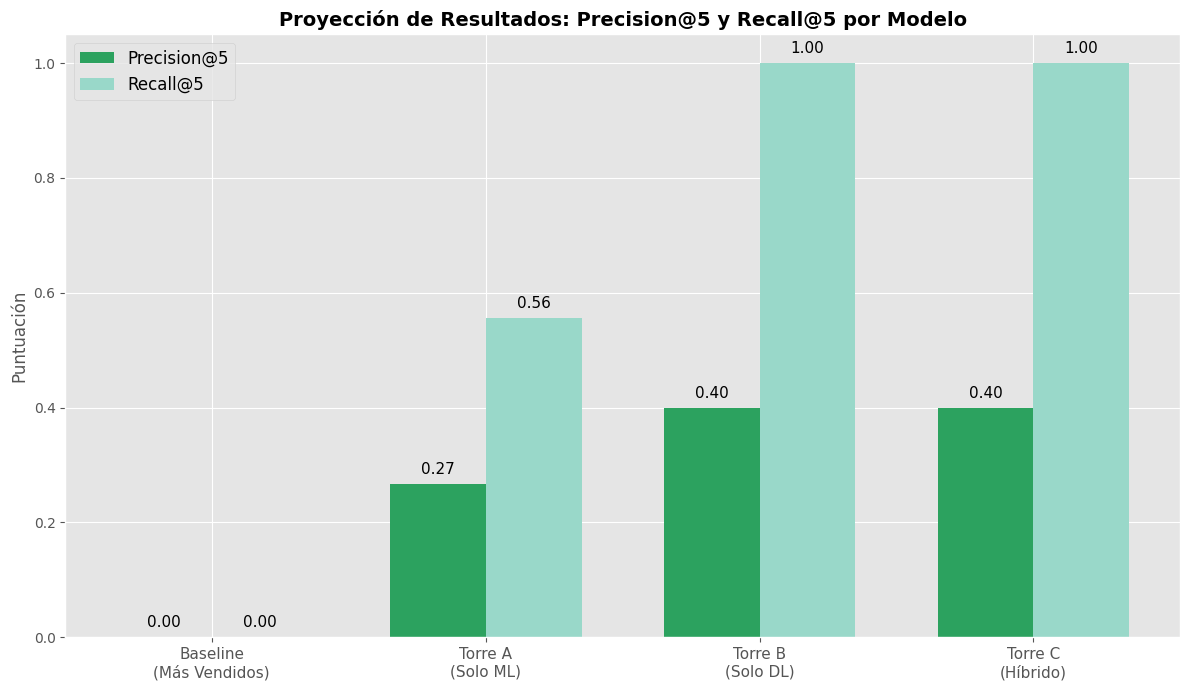

In [5]:
x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Colores institucionales / profesionales (Verdes similares a la imagen del proyecto)
rects1 = ax.bar(x - width/2, resultados_precision, width, label=f'Precision@{K}', color='#2ca25f')
rects2 = ax.bar(x + width/2, resultados_recall, width, label=f'Recall@{K}', color='#99d8c9')

# Configuraciones del gráfico
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title(f'Proyección de Resultados: Precision@{K} y Recall@{K} por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.legend(fontsize=12)

# Añadir las etiquetas de valor sobre cada barra
def autolabel(rects):
    """Agrega una etiqueta de texto sobre cada barra mostrando su altura."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

autolabel(rects1)
autolabel(rects2)

# Guardar la figura en la carpeta eda_outputs.
# plt.savefig('outputs/evaluacion_resultados.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# CELDA 6: Proyección de Resultados - NDCG@K

Calidad del Ranking - Métrica NDCG por Posición (Evolución Top-K)

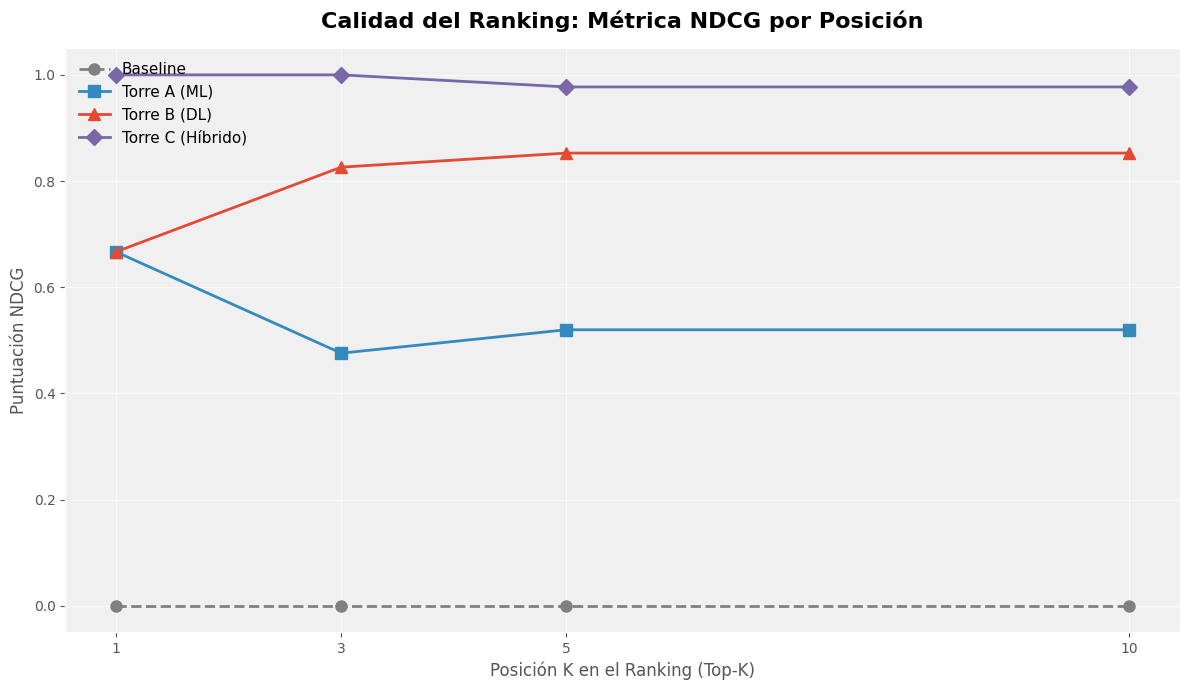

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Definir las posiciones K a evaluar en el eje X
k_values = [1, 3, 5, 10]

# -ESTRUCTURA BLINDADA CONTRA DESÓRDENES-
# Emparejamos explícitamente el nombre, las predicciones y el estilo visual
config_modelos = [
    {'nombre': 'Baseline', 'preds': preds_base, 'color': 'gray', 'line': '--', 'marker': 'o'},
    {'nombre': 'Torre A (ML)', 'preds': preds_ml, 'color': '#348ABD', 'line': '-', 'marker': 's'}
]

# Agregamos la Torre B SOLO si la variable preds_dl existe en memoria (Evita errores)
if 'preds_dl' in locals() or 'preds_dl' in globals():
    config_modelos.append({
        'nombre': 'Torre B (DL)', 'preds': preds_dl, 'color': '#E24A33', 'line': '-', 'marker': '^'
    })

# Agregamos la Torre C
if 'preds_hib' in locals() or 'preds_hib' in globals():
    config_modelos.append({
        'nombre': 'Torre C (Híbrido)', 'preds': preds_hib, 'color': '#7A68A6', 'line': '-', 'marker': 'D'
    })

# - CREACIÓN DEL GRÁFICO DE LÍNEAS -
fig, ax = plt.subplots(figsize=(12, 7))

# Calcular y dibujar cada línea de forma segura
for config in config_modelos:
    evolucion_ndcg = []
    
    for k in k_values:
        # Evaluamos el NDCG asegurando que lee la lista correcta de este modelo exacto
        score = ndcg_at_k(config['preds'], relevancia_usuarios, k)
        evolucion_ndcg.append(score)
        
    # Dibujar la línea bloqueando su estilo
    ax.plot(k_values, evolucion_ndcg, 
            label=config['nombre'], 
            color=config['color'], 
            linestyle=config['line'], 
            marker=config['marker'],
            markersize=8, linewidth=2)

# Configuraciones del gráfico
ax.set_title('Calidad del Ranking: Métrica NDCG por Posición', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Posición K en el Ranking (Top-K)', fontsize=12)
ax.set_ylabel('Puntuación NDCG', fontsize=12)

# Asegurar que el eje X solo muestre exactamente los valores 1, 3, 5 y 10
ax.set_xticks(k_values)

# Replicar la cuadrícula blanca de fondo
ax.grid(True, linestyle='-', alpha=0.7, color='white')
ax.set_facecolor('#f0f0f0') # Fondo gris claro sutil

# Posicionar la leyenda arriba a la izquierda
ax.legend(loc='upper left', fontsize=11, frameon=False)

plt.tight_layout()
plt.show()

# CELDA 7: Proyección de Resultados - Hit Rate@K


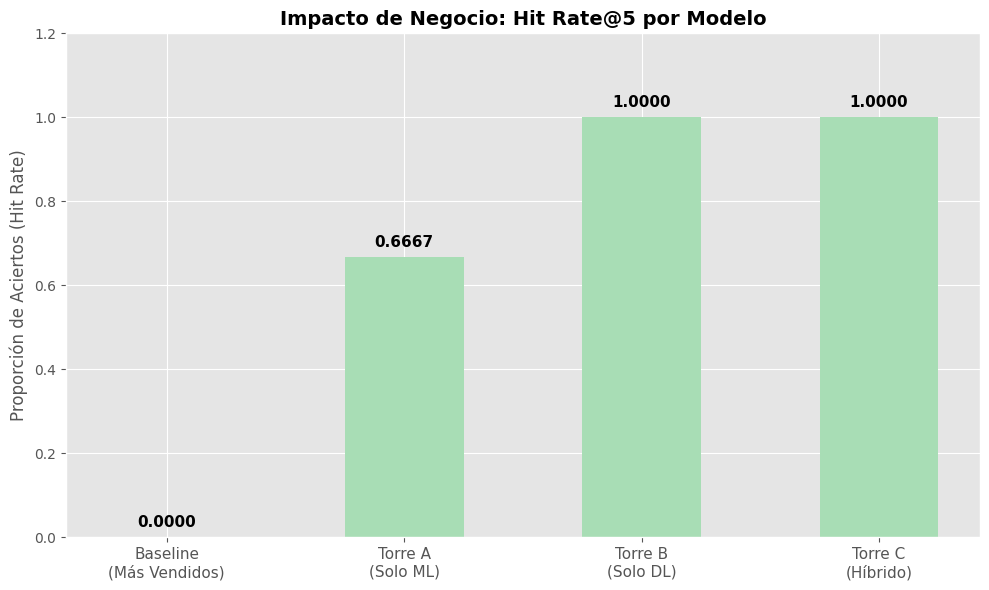

In [7]:

import matplotlib.pyplot as plt
import numpy as np

K = 5
x = np.arange(len(modelos))
width = 0.5

fig, ax = plt.subplots(figsize=(10, 6))

# Color institucional verde claro para Hit Rate
barras_hr = ax.bar(x, resultados_hr, width, color='#a8ddb5', label=f'HR@{K}')

# Configuraciones del gráfico
ax.set_ylabel('Proporción de Aciertos (Hit Rate)', fontsize=12)
ax.set_title(f'Impacto de Negocio: Hit Rate@{K} por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)

# Ajustar altura máxima dinámicamente
max_val = max(resultados_hr) if resultados_hr else 0
limite_y = max_val * 1.2 if max_val > 0 else 0.1
ax.set_ylim(0, limite_y)

# Añadir etiquetas
for barra in barras_hr:
    altura = barra.get_height()
    ax.annotate(f'{altura:.4f}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5),  
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()